In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [9]:
import pandas as pd
import numpy as np

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

In [15]:
import os

# See file path
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Load dataset
df = pd.read_excel('/kaggle/input/datasets/varadathalye/testing1/train_balanced_3class (2).xlsx')

# Clean column names
df.columns = df.columns.str.strip()

df.head()

/kaggle/input/datasets/varadathalye/testing1/train_balanced_3class (2).xlsx


,Age,Gender,Hemoglobin_g_dL,Blood_Sugar_mg_dL,Systolic_BP_mmHg,Diastolic_BP_mmHg,Cholesterol_mg_dL,O2_Saturation_pct,Heart_Rate_bpm,Respiratory_Rate_bpm,...,Nausea_Vomiting,Abdominal_Pain,Fatigue,Loss_of_Consciousness,Diabetes_History,Hypertension_History,Pain_Score_0_10,Triage_Level,Label,Time_Duration
0,68,M,12.39,115.11,140.86,65.38,122.10,97.08,55.10,25.67,...,0,0,1,0,0,0,0,Moderate,1,0-3 hrs
1,54,F,10.46,79.01,121.48,116.53,200.84,93.52,45.25,11.98,...,1,0,0,0,0,0,2,Moderate,1,0-3 hrs
2,29,M,16.61,189.62,105.55,99.03,303.54,97.76,83.10,18.32,...,0,0,1,0,1,1,2,Normal,0,0-3 hrs
3,63,M,8.61,152.59,159.39,100.57,235.51,96.07,48.13,26.15,...,1,1,1,0,0,0,0,Moderate,1,0-3 hrs
4,29,M,16.61,189.62,105.55,99.03,303.54,97.76,83.10,18.32,...,0,0,1,0,1,1,2,Normal,0,0-3 hrs


In [17]:
# 🎯 Target
y = df['Triage_Level']

# 📊 Features (remove leakage + useless columns)
X = df.drop(['Triage_Level', 'Label'], axis=1, errors='ignore')

print("Features:", X.shape)
print("Target:", y.shape)

X.head()
print(X.columns)

Features: (2100, 25)
Target: (2100,)
Index(['Age', 'Gender', 'Hemoglobin_g_dL', 'Blood_Sugar_mg_dL',
       'Systolic_BP_mmHg', 'Diastolic_BP_mmHg', 'Cholesterol_mg_dL',
       'O2_Saturation_pct', 'Heart_Rate_bpm', 'Respiratory_Rate_bpm',
       'Body_Temp_C', 'Fever', 'Cough', 'Shortness_of_Breath', 'Chest_Pain',
       'Dizziness', 'Headache', 'Nausea_Vomiting', 'Abdominal_Pain', 'Fatigue',
       'Loss_of_Consciousness', 'Diabetes_History', 'Hypertension_History',
       'Pain_Score_0_10', 'Time_Duration'],
      dtype='object')


In [19]:
# Convert categorical → numeric
X = pd.get_dummies(X)

# Encode target labels
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

# Check result
print(X.dtypes)
print(X.shape)

Age                        int64
Hemoglobin_g_dL          float64
Blood_Sugar_mg_dL        float64
Systolic_BP_mmHg         float64
Diastolic_BP_mmHg        float64
Cholesterol_mg_dL        float64
O2_Saturation_pct        float64
Heart_Rate_bpm           float64
Respiratory_Rate_bpm     float64
Body_Temp_C              float64
Fever                      int64
Cough                      int64
Shortness_of_Breath        int64
Chest_Pain                 int64
Dizziness                  int64
Headache                   int64
Nausea_Vomiting            int64
Abdominal_Pain             int64
Fatigue                    int64
Loss_of_Consciousness      int64
Diabetes_History           int64
Hypertension_History       int64
Pain_Score_0_10            int64
Gender_F                    bool
Gender_M                    bool
Time_Duration_0-3 hrs       bool
Time_Duration_3-6 hrs       bool
Time_Duration_6+ hrs        bool
dtype: object
(2100, 28)


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (1680, 28)
Test: (420, 28)


In [22]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [23]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9642857142857143
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       136
           1       0.96      0.92      0.94       130
           2       0.94      0.97      0.96       154

    accuracy                           0.96       420
   macro avg       0.97      0.96      0.96       420
weighted avg       0.96      0.96      0.96       420



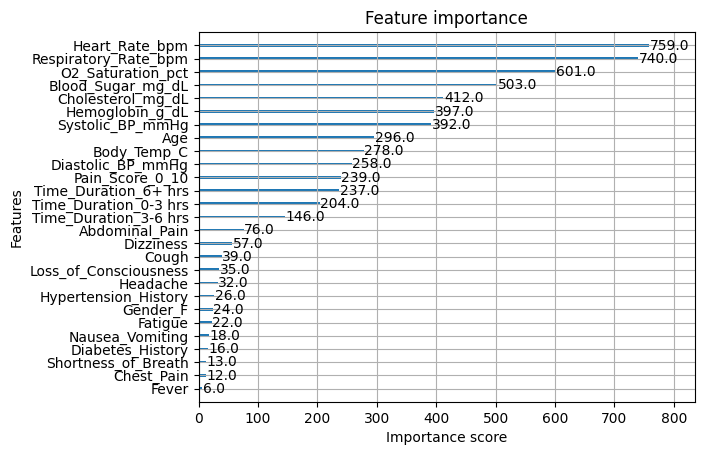

In [24]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(model)
plt.show()

In [29]:
def predict_triage(data, return_details=False):
    """
    Hybrid triage:
    1) Safety rules (override)
    2) ML prediction
    3) Human-readable guidance + reasons
    """

    reasons = []
    overrides_triggered = []

    # ---------------------------
    # 🚨 1) SAFETY OVERRIDES
    # ---------------------------
    if data.get('O2_Saturation_pct', 100) < 90:
        overrides_triggered.append("Low oxygen saturation (<90%)")

    if data.get('Respiratory_Rate_bpm', 0) > 22:
        overrides_triggered.append("High respiratory rate (>22 bpm)")

    if data.get('Heart_Rate_bpm', 0) > 130:
        overrides_triggered.append("Very high heart rate (>130 bpm)")

    # Time-based critical combo
    duration = data.get('Time_Duration', '')
    pain = data.get('Pain_Score_0_10', 0)

    if duration == '6+ hrs' and pain >= 8:
        overrides_triggered.append("Severe pain for prolonged duration (6+ hrs)")

    # If any hard rule triggers → HIGH
    if len(overrides_triggered) > 0:
        label = "High"
        reasons.extend(overrides_triggered)
        guidance = "High Risk 🚨 – Seek immediate medical attention"
        if return_details:
            return {"label": label, "guidance": guidance, "reasons": reasons}
        return guidance

    # ---------------------------
    # 🤖 2) ML PREDICTION
    # ---------------------------
    df_new = pd.DataFrame([data])
    df_new = pd.get_dummies(df_new)
    df_new = df_new.reindex(columns=X.columns, fill_value=0)

    pred = model.predict(df_new)
    label = le.inverse_transform(pred)[0]

    # ---------------------------
    # 🧠 3) LIGHT REASONS (non-diagnostic)
    # ---------------------------
    if data.get('O2_Saturation_pct', 100) < 94:
        reasons.append("Oxygen slightly low")
    if data.get('Heart_Rate_bpm', 0) > 110:
        reasons.append("Elevated heart rate")
    if data.get('Respiratory_Rate_bpm', 0) > 20:
        reasons.append("Respiratory rate above normal")
    if duration == '3-6 hrs':
        reasons.append("Symptoms persisting (3–6 hrs)")
    if duration == '6+ hrs':
        reasons.append("Symptoms prolonged (6+ hrs)")
    if data.get('Fever', 0) == 1:
        reasons.append("Fever present")

    # ---------------------------
    # 🗣️ 4) GUIDANCE
    # ---------------------------
    if label == "High":
        guidance = "High Risk 🚨 – Seek immediate medical attention"
    elif label == "Moderate":
        guidance = "Moderate Risk ⚠️ – Consult a doctor soon"
    else:
        guidance = "Low Risk ✅ – Monitor symptoms"

    if return_details:
        return {"label": label, "guidance": guidance, "reasons": reasons}
    return guidance

In [30]:
patient = {
    'Age': 60,
    'Heart_Rate_bpm': 120,
    'O2_Saturation_pct': 88,
    'Respiratory_Rate_bpm': 24,
    'Body_Temp_C': 38,
    'Systolic_BP_mmHg': 140,
    'Diastolic_BP_mmHg': 90,
    'Pain_Score_0_10': 8,
    'Time_Duration': '6+ hrs',
    'Fever': 1,
    'Cough': 1
}

print(predict_triage(patient))                      # simple output
print(predict_triage(patient, return_details=True)) # detailed (for UI/API)

High Risk 🚨 – Seek immediate medical attention
{'label': 'High', 'guidance': 'High Risk 🚨 – Seek immediate medical attention', 'reasons': ['Low oxygen saturation (<90%)', 'High respiratory rate (>22 bpm)', 'Severe pain for prolonged duration (6+ hrs)']}


In [32]:
import joblib

joblib.dump(model, 'triage_model.pkl')
joblib.dump(le, 'label_encoder.pkl')
joblib.dump(X.columns, 'model_columns.pkl')

['model_columns.pkl']